# One-Stage vs Two-Stage (Final Comparison)

This notebook does the final comparison with locked choices:
- **One-stage winner**: `global_mahalanobis`
- **Two-stage winner**: `CFLOW two-stage` (loaded from cflow outputs)

It reports matched operating points: `FPR_normal = 5%, 10%, 15%, 20%`.


In [1]:
"""import subprocess, sys

subprocess.check_call([
    sys.executable, "-m", "pip", "install",
    "--no-cache-dir", "--force-reinstall",
    "numpy==1.26.4"
])"""

'import subprocess, sys\n\nsubprocess.check_call([\n    sys.executable, "-m", "pip", "install",\n    "--no-cache-dir", "--force-reinstall",\n    "numpy==1.26.4"\n])'

In [2]:
"""import subprocess, sys
result = subprocess.run(
    [sys.executable, "-c", "import numpy; print(numpy.__version__, numpy.__file__)"],
    capture_output=True, text=True
)
print(result.stdout)  # should show 1.26.4 and a path under /usr/local/lib"""

'import subprocess, sys\nresult = subprocess.run(\n    [sys.executable, "-c", "import numpy; print(numpy.__version__, numpy.__file__)"],\n    capture_output=True, text=True\n)\nprint(result.stdout)  # should show 1.26.4 and a path under /usr/local/lib'

In [8]:
# Cell 1: Repo sync
import os, sys, subprocess
from pathlib import Path

REPO = Path('/content/FYP-code')
URL = 'https://github.com/spinelessknave8/FYP_code.git'
if not REPO.exists():
    subprocess.check_call(['git','clone',URL,str(REPO)])
else:
    subprocess.check_call(['git','-C',str(REPO),'fetch','origin'])
    subprocess.check_call(['git','-C',str(REPO),'reset','--hard','origin/main'])

os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

print('cwd:', Path.cwd())
print(subprocess.check_output(['git','-C',str(REPO),'log','--oneline','-n','2'], text=True))


cwd: /content/FYP-code
0b977c5 outputs full model
7f48baf outputs



In [9]:
# Cell 2: Preflight deps
import platform, numpy as np, torch, torchvision, sklearn
print('python:', platform.python_version())
print('numpy:', np.__version__)
print('torch:', torch.__version__)
print('torchvision:', torchvision.__version__)
print('sklearn:', sklearn.__version__)
print('cuda:', torch.cuda.is_available())


python: 3.12.12
numpy: 1.26.4
torch: 2.10.0+cu128
torchvision: 0.25.0+cu128
sklearn: 1.6.1
cuda: True


In [10]:
# Cell 3: Mount Drive + config
from google.colab import drive
from pathlib import Path
import shutil

drive.mount('/content/drive', force_remount=False)

# ---------- toggles ----------
RUN_ONE_STAGE = True            # run locked one-stage here
ONE_STAGE_FULL_DATA = True      # True => no pilot caps
HARD_RESET_ONE_STAGE = False    # delete prior one-stage final outputs

# ---------- constants ----------
SEED = 42
SPLITS = ['a','b','c','d']
FPR_TARGETS = [0.05, 0.10, 0.15, 0.20]
UNKNOWN_KNOWN_FPR_TARGET = 0.15

# if FULL_DATA=False, these caps are used
NORMAL_TRAIN_MAX = 1200
NORMAL_VAL_MAX = 250
NORMAL_TEST_MAX = 350
KNOWN_TRAIN_PER_CLASS = 180
KNOWN_VAL_PER_CLASS = 60
KNOWN_TEST_PER_CLASS = 100
UNKNOWN_TEST_MAX = 300

sev = Path('/content/drive/MyDrive/datasets/severstal')
assert sev.exists(), f'Missing {sev}'
assert (sev/'train.csv').exists(), 'Missing train.csv'
assert (sev/'train_images').exists(), 'Missing train_images'

OUT = Path('/content/drive/MyDrive/fyp_outputs/one_stage_vs_two_stage_final')
ONE_OUT = OUT / 'one_stage'
TWO_OUT = Path('/content/drive/MyDrive/fyp_outputs/severstral_cflow_two_stage_full')
OUT.mkdir(parents=True, exist_ok=True)
ONE_OUT.mkdir(parents=True, exist_ok=True)

if HARD_RESET_ONE_STAGE and ONE_OUT.exists():
    shutil.rmtree(ONE_OUT)
    ONE_OUT.mkdir(parents=True, exist_ok=True)

print('ONE_OUT:', ONE_OUT)
print('TWO_OUT:', TWO_OUT)


Mounted at /content/drive
ONE_OUT: /content/drive/MyDrive/fyp_outputs/one_stage_vs_two_stage_final/one_stage
TWO_OUT: /content/drive/MyDrive/fyp_outputs/severstral_cflow_two_stage_full


In [11]:
from pathlib import Path
print(Path('/content/drive/MyDrive/fyp_outputs/severstral_cflow_two_stage_full/cflow_two_stage_summary.csv').exists())
print(Path('/content/drive/MyDrive/fyp_outputs/severstral_cflow_two_stage_full/cflow_two_stage_mean_std.csv').exists())

True
True


In [12]:
# Cell 4: Run locked one-stage (global_mahalanobis) across all splits
import json, random, time, sys
from collections import defaultdict
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score, accuracy_score, precision_recall_fscore_support, confusion_matrix
import yaml
from pathlib import Path

sys.path.insert(0, str(Path('severstral-osr/src').resolve()))
from data import collect_single_label_defect_samples, collect_normal_image_paths, stratified_split
from src.models.resnet50 import build_resnet50
from src.models.embedding import EmbeddingExtractor
from src.osr.gaussian_mahalanobis import fit_gaussians, batch_min_mahalanobis

device = 'cuda' if torch.cuda.is_available() else 'cpu'
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
TF = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ImgDS(Dataset):
    def __init__(self, items, class_to_idx=None):
        self.items = items
        self.class_to_idx = class_to_idx
    def __len__(self):
        return len(self.items)
    def __getitem__(self, i):
        p,c = self.items[i]
        x = TF(Image.open(p).convert('RGB'))
        if self.class_to_idx is None:
            return x, c
        return x, self.class_to_idx[c]

def tau_from_fpr(normal_scores, fpr_target):
    return float(np.quantile(normal_scores, 1.0 - fpr_target))

one_rows=[]

if RUN_ONE_STAGE:
    for SPLIT in SPLITS:
        t_split0 = time.time()
        print(f'\n===== ONE-STAGE {SPLIT} =====')
        rng = random.Random(SEED)

        base = yaml.safe_load(Path('severstral-osr/configs/default.yaml').read_text())
        split_cfg = yaml.safe_load(Path(f'severstral-osr/configs/split_{SPLIT}.yaml').read_text())
        base.update(split_cfg)
        known_classes = base['known_classes']
        all_classes = [f'Class_{i}' for i in [1,2,3,4]]
        unknown_class = [c for c in all_classes if c not in known_classes][0]

        samples = collect_single_label_defect_samples(str(sev), 'train.csv', 'train_images')
        normal_paths = collect_normal_image_paths(str(sev), 'train.csv', 'train_images')
        known_samples = [s for s in samples if s[1] in known_classes]
        unknown_samples = [s for s in samples if s[1] == unknown_class]

        k_train_all, k_val_all, k_test_all = stratified_split(known_samples, train_ratio=0.7, val_ratio=0.15, seed=SEED)

        by_cls_train = defaultdict(list); by_cls_val = defaultdict(list); by_cls_test = defaultdict(list)
        for p,c in k_train_all: by_cls_train[c].append((p,c))
        for p,c in k_val_all: by_cls_val[c].append((p,c))
        for p,c in k_test_all: by_cls_test[c].append((p,c))

        known_train=[]; known_val=[]; known_test=[]
        for c in known_classes:
            rng.shuffle(by_cls_train[c]); rng.shuffle(by_cls_val[c]); rng.shuffle(by_cls_test[c])
            if ONE_STAGE_FULL_DATA:
                known_train += by_cls_train[c]
                known_val += by_cls_val[c]
                known_test += by_cls_test[c]
            else:
                known_train += by_cls_train[c][:KNOWN_TRAIN_PER_CLASS]
                known_val += by_cls_val[c][:KNOWN_VAL_PER_CLASS]
                known_test += by_cls_test[c][:KNOWN_TEST_PER_CLASS]

        rng.shuffle(normal_paths)
        if ONE_STAGE_FULL_DATA:
            n_train_cut = int(0.7 * len(normal_paths))
            n_val_cut = int(0.85 * len(normal_paths))
            normal_train = normal_paths[:n_train_cut]
            normal_val = normal_paths[n_train_cut:n_val_cut]
            normal_test = normal_paths[n_val_cut:]
        else:
            normal_train = normal_paths[:NORMAL_TRAIN_MAX]
            normal_val = normal_paths[NORMAL_TRAIN_MAX:NORMAL_TRAIN_MAX+NORMAL_VAL_MAX]
            normal_test = normal_paths[NORMAL_TRAIN_MAX+NORMAL_VAL_MAX:NORMAL_TRAIN_MAX+NORMAL_VAL_MAX+NORMAL_TEST_MAX]

        rng.shuffle(unknown_samples)
        unknown_test = unknown_samples if ONE_STAGE_FULL_DATA else unknown_samples[:UNKNOWN_TEST_MAX]

        class_to_idx = {c:i for i,c in enumerate(known_classes)}

        # train classifier (for embeddings/logits)
        t0=time.time()
        model = build_resnet50(num_classes=len(class_to_idx), pretrained=True).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
        crit = nn.CrossEntropyLoss()

        train_loader = DataLoader(ImgDS(known_train, class_to_idx), batch_size=32, shuffle=True, num_workers=2)
        val_loader = DataLoader(ImgDS(known_val, class_to_idx), batch_size=32, shuffle=False, num_workers=2)

        best_val=-1.0; best_state=None
        for ep in range(6):
            model.train()
            for x,y in train_loader:
                x,y = x.to(device), y.to(device)
                opt.zero_grad(); logits=model(x); loss=crit(logits,y); loss.backward(); opt.step()
            model.eval(); va_c=0; va_n=0
            with torch.no_grad():
                for x,y in val_loader:
                    x,y=x.to(device), y.to(device)
                    l=model(x)
                    va_c += (l.argmax(1)==y).sum().item(); va_n += x.size(0)
            va = va_c/max(1,va_n)
            if va>best_val:
                best_val=va
                best_state={k:v.cpu() for k,v in model.state_dict().items()}

        model.load_state_dict(best_state)
        model.to(device).eval()
        train_sec = time.time()-t0

        extractor = EmbeddingExtractor(model).to(device)
        def infer(items):
            loader = DataLoader(ImgDS(items, None), batch_size=32, shuffle=False, num_workers=2)
            embs, logits, raws = [], [], []
            t_infer0 = time.time()
            with torch.no_grad():
                for x,raw in loader:
                    x=x.to(device)
                    l=model(x)
                    e=extractor(x)
                    logits.append(l.cpu().numpy()); embs.append(e.cpu().numpy()); raws += list(raw)
            infer_sec = time.time()-t_infer0
            return np.concatenate(embs), np.concatenate(logits), raws, infer_sec

        NTR, _, _, _ = infer([(p,'normal') for p in normal_train])
        NVAL, LOG_NVAL, _, _ = infer([(p,'normal') for p in normal_val])
        NTEST, LOG_NTEST, _, t_n = infer([(p,'normal') for p in normal_test])
        KTR, _, RAW_KTR, _ = infer(known_train)
        KVAL, LOG_KVAL, RAW_KVAL, _ = infer(known_val)
        KTEST, LOG_KTEST, RAW_KTEST, t_k = infer(known_test)
        UTEST, LOG_UTEST, RAW_UTEST, t_u = infer(unknown_test)

        infer_total_sec = t_n + t_k + t_u
        infer_images = len(NTEST) + len(KTEST) + len(UTEST)
        infer_sec_per_image = infer_total_sec / max(1, infer_images)

        y_ktr = np.array([class_to_idx[r] for r in RAW_KTR], dtype=np.int64)

        # locked one-stage scoring: global Mahalanobis for defect screening
        mu = NTR.mean(axis=0)
        cov = np.cov(NTR, rowvar=False) + 1e-3*np.eye(NTR.shape[1])
        inv = np.linalg.inv(cov)
        score = lambda X: np.sum(((X - mu) @ inv) * (X - mu), axis=1)

        S_n_val = score(NVAL)
        S_n_test = score(NTEST)
        S_k_test = score(KTEST)
        S_u_test = score(UTEST)

        # threshold-free screening metrics
        y_screen = np.concatenate([np.zeros(len(S_n_test)), np.ones(len(S_k_test)+len(S_u_test))])
        s_screen = np.concatenate([S_n_test, S_k_test, S_u_test])
        auroc = float(roc_auc_score(y_screen, s_screen))
        auprc = float(average_precision_score(y_screen, s_screen))

        # unknown branch score (known-class mahal)
        known_params = fit_gaussians(KTR, y_ktr, 1e-3)
        U_VAL = batch_min_mahalanobis(KVAL, known_params)
        U_TEST_K = batch_min_mahalanobis(KTEST, known_params)
        U_TEST_U = batch_min_mahalanobis(UTEST, known_params)
        u_tau = float(np.quantile(U_VAL, 1.0 - UNKNOWN_KNOWN_FPR_TARGET))

        # truth for 3-way
        y3_true = np.concatenate([
            np.zeros(len(NTEST), dtype=np.int64),
            np.ones(len(KTEST), dtype=np.int64),
            np.full(len(UTEST), 2, dtype=np.int64),
        ])

        for fpr_t in FPR_TARGETS:
            tau = tau_from_fpr(S_n_val, fpr_t)
            pred_n_def = S_n_test > tau
            pred_k_def = S_k_test > tau
            pred_u_def = S_u_test > tau

            # 3-way prediction
            y_n = np.where(pred_n_def, 1, 0)
            y_k = np.where(~pred_k_def, 0, np.where(U_TEST_K > u_tau, 2, 1))
            y_u = np.where(~pred_u_def, 0, np.where(U_TEST_U > u_tau, 2, 1))
            y3_pred = np.concatenate([y_n, y_k, y_u])

            acc3 = float(accuracy_score(y3_true, y3_pred))
            bal_acc3 = float(balanced_accuracy_score(y3_true, y3_pred))
            prec, rec, f1, _ = precision_recall_fscore_support(y3_true, y3_pred, average='macro', zero_division=0)
            cm = confusion_matrix(y3_true, y3_pred, labels=[0,1,2]).tolist()

            fpr_normal = float(np.mean(pred_n_def))
            tpr_defect = float(np.mean(np.concatenate([pred_k_def, pred_u_def])))
            tpr_unknown = float(np.mean(y_u == 2))
            fpr_known_as_unknown = float(np.mean(y_k == 2))
            false_alarms_per_100 = 100.0 * fpr_normal
            specificity_normal = 1.0 - fpr_normal

            one_rows.append({
                'method_system':'one_stage_global_mahalanobis',
                'split': f'split_{SPLIT}',
                'fpr_target': fpr_t,
                'AUROC_defect_screening': auroc,
                'AUPRC_defect_screening': auprc,
                'TPR_defect@FPR': tpr_defect,
                'TPR_unknown@FPR': tpr_unknown,
                'FPR_known_as_unknown@FPR': fpr_known_as_unknown,
                'FPR_normal_realized': fpr_normal,
                'Specificity_normal': specificity_normal,
                'FalseAlarms_per_100': false_alarms_per_100,
                'acc_3way': acc3,
                'balanced_acc_3way': bal_acc3,
                'macro_precision_3way': float(prec),
                'macro_recall_3way': float(rec),
                'macro_f1_3way': float(f1),
                'cm_3way': json.dumps(cm),
                'train_sec': train_sec,
                'infer_sec_total_test': infer_total_sec,
                'infer_sec_per_image': infer_sec_per_image,
                'total_split_sec': time.time() - t_split0,
                'notes': f'unknown_known_fpr_target={UNKNOWN_KNOWN_FPR_TARGET}'
            })

    one_df = pd.DataFrame(one_rows)
    one_df.to_csv(ONE_OUT/'one_stage_locked_full_summary.csv', index=False)
    print('Saved:', ONE_OUT/'one_stage_locked_full_summary.csv', 'rows=', len(one_df))
    display(one_df.head())




===== ONE-STAGE a =====
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:02<00:00, 49.1MB/s]



===== ONE-STAGE b =====

===== ONE-STAGE c =====

===== ONE-STAGE d =====
Saved: /content/drive/MyDrive/fyp_outputs/one_stage_vs_two_stage_final/one_stage/one_stage_locked_full_summary.csv rows= 16


,method_system,split,fpr_target,AUROC_defect_screening,AUPRC_defect_screening,TPR_defect@FPR,TPR_unknown@FPR,FPR_known_as_unknown@FPR,FPR_normal_realized,Specificity_normal,...,balanced_acc_3way,macro_precision_3way,macro_recall_3way,macro_f1_3way,cm_3way,train_sec,infer_sec_total_test,infer_sec_per_image,total_split_sec,notes
0,one_stage_global_mahalanobis,split_a,0.05,0.597215,0.688226,0.079158,0.042636,0.037166,0.034989,0.965011,...,0.356788,0.479349,0.356788,0.253177,"[[855, 31, 0], [775, 54, 32], [493, 1, 22]]",739.054250,26.235055,0.011593,905.083761,unknown_known_fpr_target=0.15
1,one_stage_global_mahalanobis,split_a,0.10,0.597215,0.688226,0.127088,0.106589,0.067364,0.081264,0.918736,...,0.364617,0.443598,0.364617,0.284822,"[[814, 72, 0], [744, 59, 58], [458, 3, 55]]",739.054250,26.235055,0.011593,905.089496,unknown_known_fpr_target=0.15
2,one_stage_global_mahalanobis,split_a,0.15,0.597215,0.688226,0.193900,0.184109,0.108014,0.137698,0.862302,...,0.376678,0.423737,0.376678,0.319701,"[[764, 122, 0], [696, 72, 93], [414, 7, 95]]",739.054250,26.235055,0.011593,905.095029,unknown_known_fpr_target=0.15
3,one_stage_global_mahalanobis,split_a,0.20,0.597215,0.688226,0.262890,0.251938,0.133566,0.187359,0.812641,...,0.395123,0.437696,0.395123,0.357628,"[[720, 166, 0], [642, 104, 115], [373, 13, 130]]",739.054250,26.235055,0.011593,905.100736,unknown_known_fpr_target=0.15
4,one_stage_global_mahalanobis,split_b,0.05,0.613159,0.899541,0.137066,0.120403,0.075893,0.053047,0.946953,...,0.410845,0.466244,0.410845,0.232016,"[[839, 47, 0], [170, 37, 17], [4130, 56, 573]]",184.259652,61.894726,0.010546,370.725386,unknown_known_fpr_target=0.15


In [13]:
# Cell 5: Load CFLOW two-stage summary and harmonize columns
import pandas as pd
import numpy as np
from pathlib import Path

cflow_csv = TWO_OUT / 'cflow_two_stage_summary.csv'
if not cflow_csv.exists():
    alt = sorted([x.name for x in TWO_OUT.glob('*.csv')])
    raise RuntimeError(
        f'Missing expected CFLOW summary: {cflow_csv}\n'
        f'CSV files found under {TWO_OUT}: {alt}\n'
        'Run cflow.ipynb through final evaluation cells that write cflow_two_stage_summary.csv and cflow_two_stage_mean_std.csv.'
    )

two = pd.read_csv(cflow_csv)

# normalize expected columns
rename_map = {
    'TPR_unknown@FPR':'TPR_unknown@FPR',
    'TPR_defect@FPR':'TPR_defect@FPR',
    'FPR_known_as_def@FPR':'FPR_known_as_unknown@FPR',
}
for k,v in rename_map.items():
    if k in two.columns and v not in two.columns:
        two[v] = two[k]

two['method_system'] = 'two_stage_cflow'

# optional runtime merge (if available)
runtime_csv = TWO_OUT / 'cflow_runtime_summary.csv'
if runtime_csv.exists():
    rt = pd.read_csv(runtime_csv)
    two = two.merge(rt, on='split', how='left')
else:
    for c in ['train_sec','infer_sec_total_test','infer_sec_per_image','total_split_sec']:
        if c not in two.columns:
            two[c] = np.nan

two_path = OUT / 'two_stage_cflow_harmonized.csv'
two.to_csv(two_path, index=False)
print('Saved:', two_path)
display(two.head())



Saved: /content/drive/MyDrive/fyp_outputs/one_stage_vs_two_stage_final/two_stage_cflow_harmonized.csv


,split,fpr_target,AUROC_defect_screening,TPR_defect@FPR,TPR_unknown@FPR,FPR_known_as_def@FPR,FPR_normal_realized,two_stage_known_success,two_stage_unknown_success,stage2_unknown_rate_known_all,stage2_unknown_rate_unknown_all,tau_stage1,kappa_stage2,FPR_known_as_unknown@FPR,method_system,train_sec,infer_sec_total_test,infer_sec_per_image,total_split_sec
0,split_a,0.05,0.578871,0.491031,0.837963,0.165217,0.350000,0.139130,0.004630,0.086957,0.023148,2.021242,0.682485,0.165217,two_stage_cflow,NaN,NaN,NaN,NaN
1,split_a,0.10,0.578871,0.558296,0.902778,0.234783,0.456667,0.200000,0.004630,0.086957,0.023148,1.976155,0.682485,0.234783,two_stage_cflow,NaN,NaN,NaN,NaN
2,split_a,0.15,0.578871,0.659193,0.972222,0.365217,0.580000,0.300000,0.013889,0.086957,0.023148,1.916966,0.682485,0.365217,two_stage_cflow,NaN,NaN,NaN,NaN
3,split_a,0.20,0.578871,0.690583,0.986111,0.413043,0.660000,0.321739,0.018519,0.086957,0.023148,1.881131,0.682485,0.413043,two_stage_cflow,NaN,NaN,NaN,NaN
4,split_b,0.05,0.567178,0.377953,0.386667,0.365385,0.243333,0.360577,0.093333,0.076923,0.286667,2.023893,0.764596,0.365385,two_stage_cflow,NaN,NaN,NaN,NaN


In [14]:
# Cell 6: Merge one-stage and two-stage + compare
import pandas as pd
from pathlib import Path

one_path = ONE_OUT / 'one_stage_locked_full_summary.csv'
assert one_path.exists(), f'Missing {one_path}. Set RUN_ONE_STAGE=True and run Cell 4.'

one = pd.read_csv(one_path)
two = pd.read_csv(OUT / 'two_stage_cflow_harmonized.csv')

keep_cols = [
    'method_system','split','fpr_target','AUROC_defect_screening','AUPRC_defect_screening',
    'TPR_defect@FPR','TPR_unknown@FPR','FPR_known_as_unknown@FPR','FPR_normal_realized',
    'Specificity_normal','FalseAlarms_per_100','acc_3way','balanced_acc_3way','macro_f1_3way',
    'train_sec','infer_sec_per_image','total_split_sec'
]
for c in keep_cols:
    if c not in two.columns:
        two[c] = pd.NA

cmp_df = pd.concat([one[keep_cols], two[keep_cols]], ignore_index=True)
cmp_df.to_csv(OUT / 'one_stage_vs_two_stage_full_comparison.csv', index=False)

print('Per-split rows:')
display(cmp_df.sort_values(['split','fpr_target','method_system']))

summary = (cmp_df.groupby(['method_system','fpr_target'])
           [['AUROC_defect_screening','TPR_defect@FPR','TPR_unknown@FPR','FPR_known_as_unknown@FPR','FPR_normal_realized','acc_3way','balanced_acc_3way','macro_f1_3way','train_sec','infer_sec_per_image','total_split_sec']]
           .agg(['mean','std'])
           .reset_index())
summary.columns = ['_'.join(c).strip('_') for c in summary.columns.values]
summary.to_csv(OUT / 'one_stage_vs_two_stage_mean_std.csv', index=False)

print('Mean/std:')
display(summary)
print('Saved:', OUT / 'one_stage_vs_two_stage_full_comparison.csv')
print('Saved:', OUT / 'one_stage_vs_two_stage_mean_std.csv')


/tmp/ipykernel_1184/3971234048.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cmp_df = pd.concat([one[keep_cols], two[keep_cols]], ignore_index=True)


Per-split rows:


,method_system,split,fpr_target,AUROC_defect_screening,AUPRC_defect_screening,TPR_defect@FPR,TPR_unknown@FPR,FPR_known_as_unknown@FPR,FPR_normal_realized,Specificity_normal,FalseAlarms_per_100,acc_3way,balanced_acc_3way,macro_f1_3way,train_sec,infer_sec_per_image,total_split_sec
0,one_stage_global_mahalanobis,split_a,0.05,0.597215,0.688226,0.079158,0.042636,0.037166,0.034989,0.965011,3.498871,0.411401,0.356788,0.253177,739.054250,0.011593,905.083761
16,two_stage_cflow,split_a,0.05,0.578871,NaN,0.491031,0.837963,0.165217,0.350000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,one_stage_global_mahalanobis,split_a,0.10,0.597215,0.688226,0.127088,0.106589,0.067364,0.081264,0.918736,8.126411,0.410075,0.364617,0.284822,739.054250,0.011593,905.089496
17,two_stage_cflow,split_a,0.10,0.578871,NaN,0.558296,0.902778,0.234783,0.456667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,one_stage_global_mahalanobis,split_a,0.15,0.597215,0.688226,0.193900,0.184109,0.108014,0.137698,0.862302,13.769752,0.411401,0.376678,0.319701,739.054250,0.011593,905.095029
18,two_stage_cflow,split_a,0.15,0.578871,NaN,0.659193,0.972222,0.365217,0.580000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,one_stage_global_mahalanobis,split_a,0.20,0.597215,0.688226,0.262890,0.251938,0.133566,0.187359,0.812641,18.735892,0.421564,0.395123,0.357628,739.054250,0.011593,905.100736
19,two_stage_cflow,split_a,0.20,0.578871,NaN,0.690583,0.986111,0.413043,0.660000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,one_stage_global_mahalanobis,split_b,0.05,0.613159,0.899541,0.137066,0.120403,0.075893,0.053047,0.946953,5.304740,0.246890,0.410845,0.232016,184.259652,0.010546,370.725386
20,two_stage_cflow,split_b,0.05,0.567178,NaN,0.377953,0.386667,0.365385,0.243333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Mean/std:


,method_system,fpr_target,AUROC_defect_screening_mean,AUROC_defect_screening_std,TPR_defect@FPR_mean,TPR_defect@FPR_std,TPR_unknown@FPR_mean,TPR_unknown@FPR_std,FPR_known_as_unknown@FPR_mean,FPR_known_as_unknown@FPR_std,...,balanced_acc_3way_mean,balanced_acc_3way_std,macro_f1_3way_mean,macro_f1_3way_std,train_sec_mean,train_sec_std,infer_sec_per_image_mean,infer_sec_per_image_std,total_split_sec_mean,total_split_sec_std
0,one_stage_global_mahalanobis,0.05,0.650910,0.100137,0.213120,0.162041,0.059702,0.046850,0.086899,0.039384,...,0.405285,0.045659,0.305815,0.093944,439.266448,228.382933,0.011094,0.000462,610.643499,220.619598
1,one_stage_global_mahalanobis,0.10,0.650910,0.100137,0.297756,0.194867,0.098581,0.074733,0.106255,0.029074,...,0.426796,0.056280,0.342291,0.094842,439.266448,228.382933,0.011094,0.000462,610.653623,220.613201
2,one_stage_global_mahalanobis,0.15,0.650910,0.100137,0.358176,0.182257,0.129991,0.102753,0.126574,0.015739,...,0.434124,0.054092,0.358430,0.086081,439.266448,228.382933,0.011094,0.000462,610.662936,220.608243
3,one_stage_global_mahalanobis,0.20,0.650910,0.100137,0.419414,0.177251,0.155994,0.128763,0.136422,0.008865,...,0.441108,0.050995,0.372410,0.082768,439.266448,228.382933,0.011094,0.000462,610.669870,220.606513
4,two_stage_cflow,0.05,0.533001,0.049221,0.345079,0.141471,0.352824,0.358793,0.320816,0.104654,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,two_stage_cflow,0.10,0.533001,0.049221,0.431945,0.155793,0.407361,0.375002,0.420440,0.134847,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,two_stage_cflow,0.15,0.533001,0.049221,0.520197,0.161231,0.480556,0.383465,0.524221,0.112071,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,two_stage_cflow,0.20,0.533001,0.049221,0.573038,0.145895,0.534028,0.354774,0.580917,0.117618,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Saved: /content/drive/MyDrive/fyp_outputs/one_stage_vs_two_stage_final/one_stage_vs_two_stage_full_comparison.csv
Saved: /content/drive/MyDrive/fyp_outputs/one_stage_vs_two_stage_final/one_stage_vs_two_stage_mean_std.csv


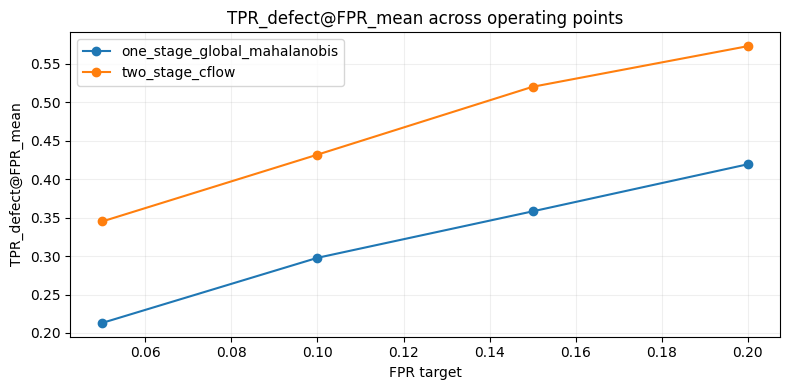

Saved: /content/drive/MyDrive/fyp_outputs/one_stage_vs_two_stage_final/plot_TPR_defect@FPR_mean.png


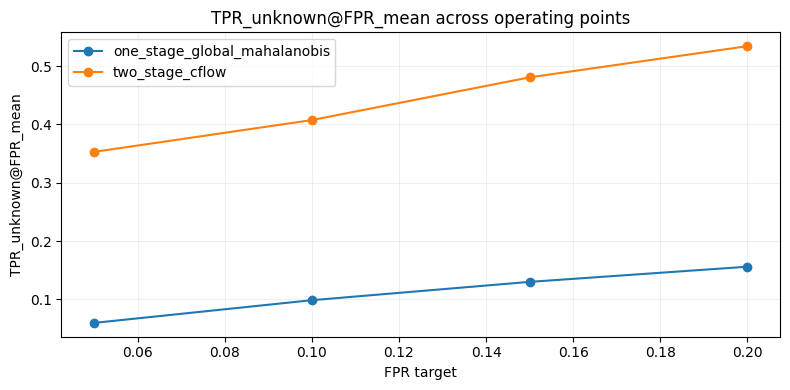

Saved: /content/drive/MyDrive/fyp_outputs/one_stage_vs_two_stage_final/plot_TPR_unknown@FPR_mean.png


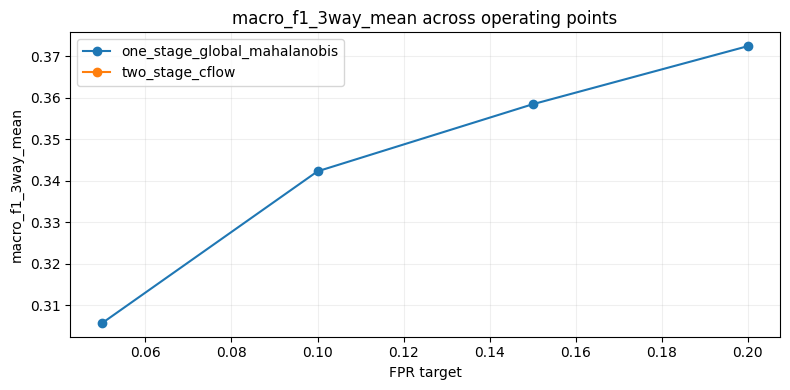

Saved: /content/drive/MyDrive/fyp_outputs/one_stage_vs_two_stage_final/plot_macro_f1_3way_mean.png


In [15]:
# Cell 7: Quick plots
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

summary = pd.read_csv(OUT / 'one_stage_vs_two_stage_mean_std.csv')

for metric in ['TPR_defect@FPR_mean','TPR_unknown@FPR_mean','macro_f1_3way_mean']:
    plt.figure(figsize=(8,4))
    for m in summary['method_system'].unique():
        d = summary[summary['method_system']==m].sort_values('fpr_target')
        plt.plot(d['fpr_target'], d[metric], marker='o', label=m)
    plt.xlabel('FPR target')
    plt.ylabel(metric)
    plt.title(metric + ' across operating points')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    outp = OUT / f'plot_{metric}.png'
    plt.savefig(outp, dpi=150)
    plt.show()
    print('Saved:', outp)


## Notes
- This notebook is the final comparison surface for one-stage winner vs two-stage CFLOW.
- If CFLOW CSV is missing, run `severstral-osr/notebooks/cflow.ipynb` first.
- For runtime parity, add `cflow_runtime_summary.csv` in CFLOW output folder (optional merge supported).


In [17]:
# Recompute/complete CFLOW metrics from cached artifacts + include inference timing + merge final comparison
from pathlib import Path
import json, time
import numpy as np
import pandas as pd
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    balanced_accuracy_score, precision_recall_fscore_support, confusion_matrix
)

# ---- paths ----
OUT = Path('/content/drive/MyDrive/fyp_outputs/one_stage_vs_two_stage_final')
ONE_PATH = OUT / 'one_stage' / 'one_stage_locked_full_summary.csv'
CFLOW_ROOT = Path('/content/drive/MyDrive/fyp_outputs/severstral_cflow_two_stage_full')

SUMMARY_CFLOW = CFLOW_ROOT / 'cflow_two_stage_summary.csv'
MANIFEST_DIR = CFLOW_ROOT / 'manifests'
STAGE1_DIR = CFLOW_ROOT / 'stage1_scores'
STAGE2_DIR = CFLOW_ROOT / 'stage2'

assert ONE_PATH.exists(), f"Missing one-stage summary: {ONE_PATH}"
assert SUMMARY_CFLOW.exists(), f"Missing CFLOW summary: {SUMMARY_CFLOW}"
assert MANIFEST_DIR.exists(), f"Missing {MANIFEST_DIR}"
assert STAGE1_DIR.exists(), f"Missing {STAGE1_DIR}"
assert STAGE2_DIR.exists(), f"Missing {STAGE2_DIR}"

# ---- constants ----
STAGE2_UNKNOWN_Q = 0.10
CFLOW_TRAIN_SEC = 20852  # 5h 47m 32s
FPR_TARGETS = [0.05, 0.10, 0.15, 0.20]
SPLITS = ['a', 'b', 'c', 'd']

def softmax(x):
    x = x - x.max(axis=1, keepdims=True)
    ex = np.exp(x)
    return ex / ex.sum(axis=1, keepdims=True)

rows = []

for s in SPLITS:
    split = f"split_{s}"

    # stage1 scores
    t0_stage1 = time.perf_counter()
    st1_main = np.load(STAGE1_DIR / f"{split}_main.npz")
    st1_val  = np.load(STAGE1_DIR / f"{split}_val.npz")
    stage1_load_sec = time.perf_counter() - t0_stage1

    s_n_test = st1_main["normal_scores"]
    s_k_test = st1_main["known_scores"]
    s_u_test = st1_main["unknown_scores"]
    s_n_val  = st1_val["normal_scores"]

    # stage2 logits
    t0_stage2 = time.perf_counter()
    st2 = np.load(STAGE2_DIR / f"{split}_logits.npz")
    lk_val = st2["logits_known_val"]
    lk_test = st2["logits_known_test"]
    lu_test = st2["logits_unknown_test"]
    stage2_load_sec = time.perf_counter() - t0_stage2

    # stage2 unknown threshold
    conf_k_val = softmax(lk_val).max(axis=1)
    kappa = np.quantile(conf_k_val, STAGE2_UNKNOWN_Q)

    conf_k_test = softmax(lk_test).max(axis=1)
    conf_u_test = softmax(lu_test).max(axis=1)

    # threshold-free screening
    y_bin = np.concatenate([
        np.zeros(len(s_n_test), dtype=np.int64),
        np.ones(len(s_k_test) + len(s_u_test), dtype=np.int64)
    ])
    sc_bin = np.concatenate([s_n_test, s_k_test, s_u_test])
    auroc = float(roc_auc_score(y_bin, sc_bin)) if len(np.unique(y_bin)) > 1 else float("nan")
    auprc = float(average_precision_score(y_bin, sc_bin)) if len(np.unique(y_bin)) > 1 else float("nan")

    # inference timing proxy from actual cached pass processing
    # (post-load scoring + decision ops across all operating points)
    t0_eval = time.perf_counter()

    split_rows = []
    for fpr_t in FPR_TARGETS:
        tau = np.quantile(s_n_val, 1.0 - fpr_t)

        pred_n_def = s_n_test > tau
        pred_k_def = s_k_test > tau
        pred_u_def = s_u_test > tau

        known_unknown = conf_k_test < kappa
        unknown_unknown = conf_u_test < kappa

        # 3-way labels: 0=normal, 1=known defect, 2=unknown defect
        y_true_3 = np.concatenate([
            np.zeros(len(s_n_test), dtype=np.int64),
            np.ones(len(s_k_test), dtype=np.int64),
            np.full(len(s_u_test), 2, dtype=np.int64),
        ])

        y_n = np.where(pred_n_def, 1, 0)
        y_k = np.where(~pred_k_def, 0, np.where(known_unknown, 2, 1))
        y_u = np.where(~pred_u_def, 0, np.where(unknown_unknown, 2, 1))
        y_pred_3 = np.concatenate([y_n, y_k, y_u])

        acc3 = float(accuracy_score(y_true_3, y_pred_3))
        bal3 = float(balanced_accuracy_score(y_true_3, y_pred_3))
        p, r, f1, _ = precision_recall_fscore_support(y_true_3, y_pred_3, average="macro", zero_division=0)
        cm = confusion_matrix(y_true_3, y_pred_3, labels=[0, 1, 2]).tolist()

        fpr_normal = float(np.mean(pred_n_def))
        tpr_defect = float(np.mean(np.concatenate([pred_k_def, pred_u_def])))
        tpr_unknown = float(np.mean(y_u == 2))
        fpr_known_as_unknown = float(np.mean(y_k == 2))

        split_rows.append({
            "method_system": "two_stage_cflow",
            "split": split,
            "fpr_target": float(fpr_t),
            "AUROC_defect_screening": auroc,
            "AUPRC_defect_screening": auprc,
            "TPR_defect@FPR": tpr_defect,
            "TPR_unknown@FPR": tpr_unknown,
            "FPR_known_as_unknown@FPR": fpr_known_as_unknown,
            "FPR_normal_realized": fpr_normal,
            "Specificity_normal": float(1.0 - fpr_normal),
            "FalseAlarms_per_100": float(100.0 * fpr_normal),
            "acc_3way": acc3,
            "balanced_acc_3way": bal3,
            "macro_precision_3way": float(p),
            "macro_recall_3way": float(r),
            "macro_f1_3way": float(f1),
            "cm_3way": json.dumps(cm),
        })

    eval_sec = time.perf_counter() - t0_eval

    # inference total approximated as load + decision/runtime compute for this split test pass
    infer_total_sec = stage1_load_sec + stage2_load_sec + eval_sec
    infer_images = len(s_n_test) + len(s_k_test) + len(s_u_test)
    infer_sec_per_image = infer_total_sec / max(1, infer_images)

    for row in split_rows:
        row["train_sec"] = float(CFLOW_TRAIN_SEC)
        row["infer_sec_total_test"] = float(infer_total_sec)
        row["infer_sec_per_image"] = float(infer_sec_per_image)
        row["total_split_sec"] = float(CFLOW_TRAIN_SEC + infer_total_sec)
        row["notes"] = "recomputed from cached stage1/stage2; train_sec user-provided"
        rows.append(row)

    print(f"{split}: infer_total_sec={infer_total_sec:.3f}s, infer_sec_per_image={infer_sec_per_image:.6f}s")

two_enriched = pd.DataFrame(rows)
two_enriched_path = OUT / "two_stage_cflow_enriched_from_cache.csv"
two_enriched.to_csv(two_enriched_path, index=False)
print("Saved:", two_enriched_path)

# merge with one-stage
one = pd.read_csv(ONE_PATH)
keep_cols = [
    'method_system','split','fpr_target','AUROC_defect_screening','AUPRC_defect_screening',
    'TPR_defect@FPR','TPR_unknown@FPR','FPR_known_as_unknown@FPR','FPR_normal_realized',
    'Specificity_normal','FalseAlarms_per_100','acc_3way','balanced_acc_3way','macro_f1_3way',
    'train_sec','infer_sec_per_image','total_split_sec'
]

for c in keep_cols:
    if c not in one.columns:
        one[c] = np.nan

cmp_df = pd.concat([one[keep_cols], two_enriched[keep_cols]], ignore_index=True)
cmp_path = OUT / "one_stage_vs_two_stage_full_comparison.csv"
cmp_df.to_csv(cmp_path, index=False)

summary = (
    cmp_df.groupby(['method_system', 'fpr_target'])[
        ['AUROC_defect_screening','AUPRC_defect_screening','TPR_defect@FPR','TPR_unknown@FPR',
          'FPR_known_as_unknown@FPR','FPR_normal_realized','acc_3way','balanced_acc_3way',
          'macro_f1_3way','train_sec','infer_sec_per_image','total_split_sec']
    ]
    .agg(['mean', 'std'])
    .reset_index()
)
summary.columns = ['_'.join(c).strip('_') for c in summary.columns.values]
summary_path = OUT / "one_stage_vs_two_stage_mean_std.csv"
summary.to_csv(summary_path, index=False)

print("Saved:", cmp_path)
print("Saved:", summary_path)

print("\n=== Full combined table ===")
display(cmp_df.sort_values(['split','fpr_target','method_system']))

print("\n=== Mean/std summary ===")
display(summary)

split_a: infer_total_sec=0.044s, infer_sec_per_image=0.000058s
split_b: infer_total_sec=0.039s, infer_sec_per_image=0.000048s
split_c: infer_total_sec=0.036s, infer_sec_per_image=0.000058s
split_d: infer_total_sec=0.035s, infer_sec_per_image=0.000043s
Saved: /content/drive/MyDrive/fyp_outputs/one_stage_vs_two_stage_final/two_stage_cflow_enriched_from_cache.csv
Saved: /content/drive/MyDrive/fyp_outputs/one_stage_vs_two_stage_final/one_stage_vs_two_stage_full_comparison.csv
Saved: /content/drive/MyDrive/fyp_outputs/one_stage_vs_two_stage_final/one_stage_vs_two_stage_mean_std.csv

=== Full combined table ===


,method_system,split,fpr_target,AUROC_defect_screening,AUPRC_defect_screening,TPR_defect@FPR,TPR_unknown@FPR,FPR_known_as_unknown@FPR,FPR_normal_realized,Specificity_normal,FalseAlarms_per_100,acc_3way,balanced_acc_3way,macro_f1_3way,train_sec,infer_sec_per_image,total_split_sec
0,one_stage_global_mahalanobis,split_a,0.05,0.597215,0.688226,0.079158,0.042636,0.037166,0.034989,0.965011,3.498871,0.411401,0.356788,0.253177,739.054250,0.011593,905.083761
16,two_stage_cflow,split_a,0.05,0.578871,0.679274,0.491031,0.004630,0.008696,0.350000,0.650000,35.000000,0.310992,0.270384,0.226657,20852.000000,0.000058,20852.043579
1,one_stage_global_mahalanobis,split_a,0.10,0.597215,0.688226,0.127088,0.106589,0.067364,0.081264,0.918736,8.126411,0.410075,0.364617,0.284822,739.054250,0.011593,905.089496
17,two_stage_cflow,split_a,0.10,0.578871,0.679274,0.558296,0.004630,0.017391,0.456667,0.543333,45.666667,0.286863,0.255118,0.222218,20852.000000,0.000058,20852.043579
2,one_stage_global_mahalanobis,split_a,0.15,0.597215,0.688226,0.193900,0.184109,0.108014,0.137698,0.862302,13.769752,0.411401,0.376678,0.319701,739.054250,0.011593,905.095029
18,two_stage_cflow,split_a,0.15,0.578871,0.679274,0.659193,0.013889,0.017391,0.580000,0.420000,58.000000,0.280161,0.260572,0.231480,20852.000000,0.000058,20852.043579
3,one_stage_global_mahalanobis,split_a,0.20,0.597215,0.688226,0.262890,0.251938,0.133566,0.187359,0.812641,18.735892,0.421564,0.395123,0.357628,739.054250,0.011593,905.100736
19,two_stage_cflow,split_a,0.20,0.578871,0.679274,0.690583,0.018519,0.026087,0.660000,0.340000,66.000000,0.261394,0.248492,0.219452,20852.000000,0.000058,20852.043579
4,one_stage_global_mahalanobis,split_b,0.05,0.613159,0.899541,0.137066,0.120403,0.075893,0.053047,0.946953,5.304740,0.246890,0.410845,0.232016,184.259652,0.010546,370.725386
20,two_stage_cflow,split_b,0.05,0.567178,0.712409,0.377953,0.093333,0.004808,0.243333,0.756667,24.333333,0.408416,0.403526,0.348868,20852.000000,0.000048,20852.038874



=== Mean/std summary ===


,method_system,fpr_target,AUROC_defect_screening_mean,AUROC_defect_screening_std,AUPRC_defect_screening_mean,AUPRC_defect_screening_std,TPR_defect@FPR_mean,TPR_defect@FPR_std,TPR_unknown@FPR_mean,TPR_unknown@FPR_std,...,balanced_acc_3way_mean,balanced_acc_3way_std,macro_f1_3way_mean,macro_f1_3way_std,train_sec_mean,train_sec_std,infer_sec_per_image_mean,infer_sec_per_image_std,total_split_sec_mean,total_split_sec_std
0,one_stage_global_mahalanobis,0.05,0.650910,0.100137,0.799335,0.098087,0.213120,0.162041,0.059702,0.046850,...,0.405285,0.045659,0.305815,0.093944,439.266448,228.382933,0.011094,0.000462,610.643499,220.619598
1,one_stage_global_mahalanobis,0.10,0.650910,0.100137,0.799335,0.098087,0.297756,0.194867,0.098581,0.074733,...,0.426796,0.056280,0.342291,0.094842,439.266448,228.382933,0.011094,0.000462,610.653623,220.613201
2,one_stage_global_mahalanobis,0.15,0.650910,0.100137,0.799335,0.098087,0.358176,0.182257,0.129991,0.102753,...,0.434124,0.054092,0.358430,0.086081,439.266448,228.382933,0.011094,0.000462,610.662936,220.608243
3,one_stage_global_mahalanobis,0.20,0.650910,0.100137,0.799335,0.098087,0.419414,0.177251,0.155994,0.128763,...,0.441108,0.050995,0.372410,0.082768,439.266448,228.382933,0.011094,0.000462,610.669870,220.606513
4,two_stage_cflow,0.05,0.533001,0.049221,0.650312,0.058964,0.345079,0.141471,0.031157,0.042007,...,0.358834,0.064822,0.311169,0.056755,20852.000000,0.000000,0.000052,0.000007,20852.038439,0.003770
5,two_stage_cflow,0.10,0.533001,0.049221,0.650312,0.058964,0.431945,0.155793,0.045324,0.047586,...,0.348871,0.070103,0.312477,0.060369,20852.000000,0.000000,0.000052,0.000007,20852.038439,0.003770
6,two_stage_cflow,0.15,0.533001,0.049221,0.650312,0.058964,0.520197,0.161231,0.061806,0.058315,...,0.342268,0.068874,0.310127,0.056887,20852.000000,0.000000,0.000052,0.000007,20852.038439,0.003770
7,two_stage_cflow,0.20,0.533001,0.049221,0.650312,0.058964,0.573038,0.145895,0.074630,0.065371,...,0.337915,0.073509,0.306265,0.063819,20852.000000,0.000000,0.000052,0.000007,20852.038439,0.003770
